In [1]:
import torch
import torch.nn as nn 
import torch.nn.functional as F

In [2]:
in_size = 1

hid1_size = 16 # First hidden state with 16 feature maps
hid2_size = 32 # 2nd hidden state with 32 feature maps

out_size = 10 # 10 classes for MNIST

k_conv_size = 5

In [3]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(in_size, hid1_size, k_conv_size),
            nn.BatchNorm2d(hid1_size), # Used to 0 center and normalize output of each convolution, basically a usual normalisation 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(hid1_size, hid2_size, k_conv_size),
            nn.BatchNorm2d(hid2_size),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.fc = nn.Linear(512, out_size) # 512 is the size of the vector after we flatten the images obtained from the convolutions and pooling layers
    
    def forward(self, x):
        out = self.layer1(x)
        print(out.shape)

        out = self.layer2(out)
        print(out.shape)

        out = out.reshape(out.size(0), -1) # resizing the images
        print(out.shape)

        out = self.fc(out) # This layer will be fed into the nn.Linear
        print(out.shape)

        return out # For new we only leave the output like that
        

In [4]:
model = ConvNet()

In [5]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [6]:
model.to(device)

ConvNet(
  (layer1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Linear(in_features=512, out_features=10, bias=True)
)

In [7]:
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

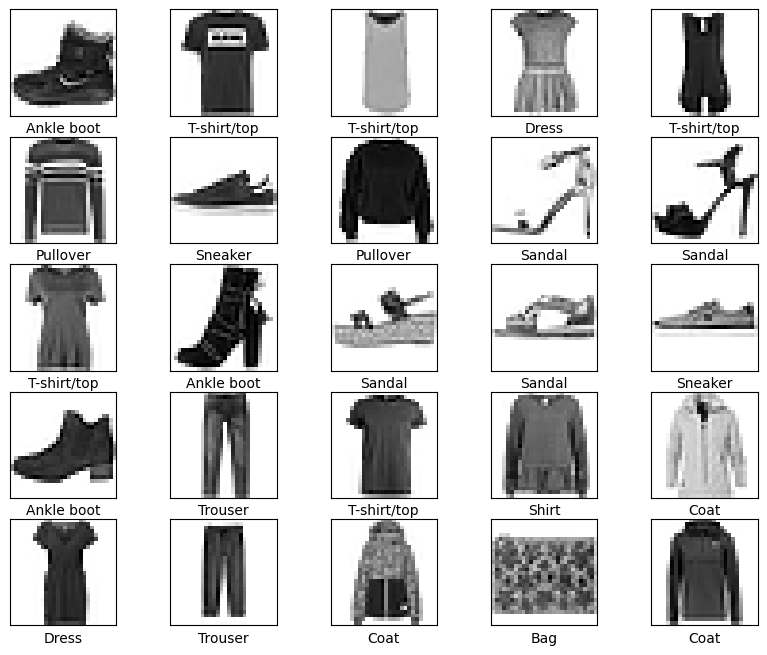

In [8]:
# Load the Fashion MNIST dataset
(train_images, train_labels), (test_images, test_labels) = keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Vizualize the first 25 images from the training set   
plt.figure(figsize=(10, 8))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()


In [9]:
# Train and test size for split
print("train_images shape:", train_images.shape)
print("test_images shape:", test_images.shape)

train_images shape: (60000, 28, 28)
test_images shape: (10000, 28, 28)


In [10]:
# Normalize the pixel values to be between 0 and 1
train_images = train_images / 255.0
test_images = test_images / 255.0

In [11]:
tensor_train_img = torch.Tensor(train_images).float().unsqueeze(1).to(device)
tensor_test_img = torch.tensor(test_images).float().unsqueeze(1).to(device)

tensor_train_labels = torch.tensor(train_labels, dtype=torch.long).to(device)
tensor_test_labels = torch.tensor(test_labels, dtype=torch.long).to(device)

In [12]:
tensor_train_img.shape # Must have one channes, that means it's a greyscale image

torch.Size([60000, 1, 28, 28])

In [13]:
tensor_train_labels.shape

torch.Size([60000])

In [ ]:
# Loading data into batches
from torch.utils.data import TensorDataset, DataLoader
import gc

In [112]:
train_dataset =  TensorDataset(tensor_train_img, tensor_train_labels)
test_dataset  =  TensorDataset(tensor_test_img, tensor_test_labels)

batch_size    = 1200

train_loader  = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)

In [113]:
model = ConvNet().to(device)

lr = 0.0001
criterion = nn.CrossEntropyLoss() # Used for softmax
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

num_epochs = 20

In [114]:
torch.cuda.empty_cache()
gc.collect()

3413

In [115]:
loss_values = [] # Make sure to reset this one to an empty vector, otherwise after every training session it will append new loss values

for epoch in range(1, num_epochs + 1):
    model.train()

    for i, (images_batch, labels_batch) in enumerate(train_loader):

        images_batch = images_batch.to(device)
        labels_batch = labels_batch.to(device)

        outputs = model(images_batch) # If previous tensors are not already set to(device) they will need to be set here
        loss = criterion(outputs, labels_batch)

        optimizer.zero_grad() # Clear gradients from previous iteration
        loss.backward()       # Compute gradients  
        optimizer.step()      # Update model parameters

        print('Epoch - %d, loss -%0.5f ' %(epoch, loss.item()))
        loss_values.append(loss.item())
    

torch.Size([1200, 16, 12, 12])
torch.Size([1200, 32, 4, 4])
torch.Size([1200, 512])
torch.Size([1200, 10])
Epoch - 1, loss -2.55731 
torch.Size([1200, 16, 12, 12])
torch.Size([1200, 32, 4, 4])
torch.Size([1200, 512])
torch.Size([1200, 10])
Epoch - 1, loss -2.47988 
torch.Size([1200, 16, 12, 12])
torch.Size([1200, 32, 4, 4])
torch.Size([1200, 512])
torch.Size([1200, 10])
Epoch - 1, loss -2.44121 
torch.Size([1200, 16, 12, 12])
torch.Size([1200, 32, 4, 4])
torch.Size([1200, 512])
torch.Size([1200, 10])
Epoch - 1, loss -2.38243 
torch.Size([1200, 16, 12, 12])
torch.Size([1200, 32, 4, 4])
torch.Size([1200, 512])
torch.Size([1200, 10])
Epoch - 1, loss -2.37223 
torch.Size([1200, 16, 12, 12])
torch.Size([1200, 32, 4, 4])
torch.Size([1200, 512])
torch.Size([1200, 10])
Epoch - 1, loss -2.31534 
torch.Size([1200, 16, 12, 12])
torch.Size([1200, 32, 4, 4])
torch.Size([1200, 512])
torch.Size([1200, 10])
Epoch - 1, loss -2.26888 
torch.Size([1200, 16, 12, 12])
torch.Size([1200, 32, 4, 4])
torch.Siz

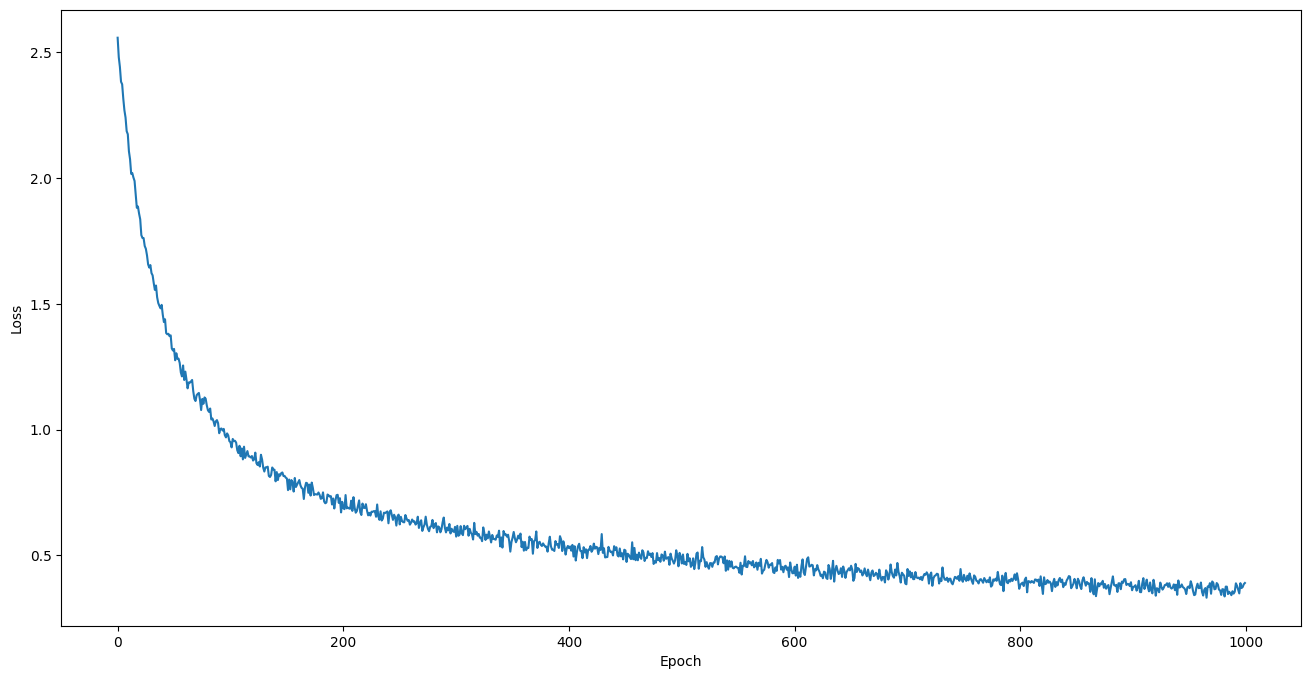

In [117]:
plt.figure(figsize=[16,8])
plt.plot(range(0, 1000), loss_values)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()